In [60]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime

In [15]:
folder_path = r"C:\Users\leroquan\Documents\Data\measures\lucerne\20260116_drifters_test"

data_drifters = []
for csv_file in glob.glob(os.path.join(folder_path, "*.csv")):
    data_drifters.append(pd.read_csv(csv_file))

In [16]:
df_drifters = pd.concat(data_drifters)

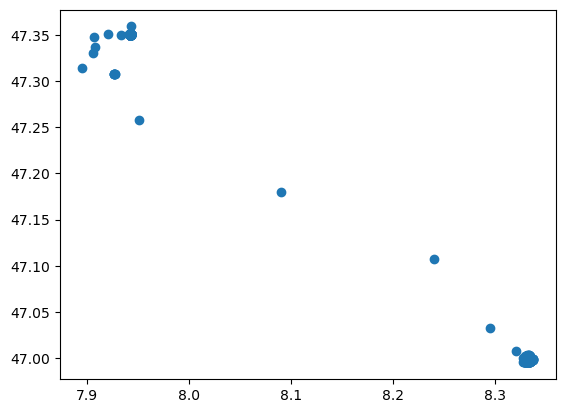

In [17]:
i = 0
plt.scatter(data_drifters[i]['lon'], data_drifters[i]['lat'])

In [18]:
df_drifters['date_utc'] = pd.to_datetime(df_drifters['time'], unit='ms', utc=True)

In [55]:
df_filtered = df_drifters[
    (df_drifters['date_utc'] >= '2026-01-16 08:30') &
    (df_drifters['date_utc'] <= '2026-01-16 13:30')
].reset_index()


df_filtered.to_csv(os.path.join(folder_path, "filtered_data.csv"))

In [59]:
df_filtered

,index,time,lon,lat,deveui,devname,speed_raw,course_raw,battery,date_utc
0,6289,1768552424995,8.337512,46.999024,A840410C5D5BAC14,A840410C5D5BAC14,0,0,4.002,2026-01-16 08:33:44.995000+00:00
1,6290,1768552745800,8.337325,46.998968,A840410C5D5BAC14,A840410C5D5BAC14,0,0,4.002,2026-01-16 08:39:05.800000+00:00
2,6291,1768553067480,8.337501,46.998636,A840410C5D5BAC14,A840410C5D5BAC14,0,0,4.002,2026-01-16 08:44:27.480000+00:00
3,6292,1768553390246,8.337666,46.998532,A840410C5D5BAC14,A840410C5D5BAC14,0,0,4.002,2026-01-16 08:49:50.246000+00:00
4,6293,1768553715982,8.337101,46.998576,A840410C5D5BAC14,A840410C5D5BAC14,0,0,4.002,2026-01-16 08:55:15.982000+00:00
...,...,...,...,...,...,...,...,...,...,...
1443,5289,1768568668261,8.329899,46.995760,A84041EE8F5BAC2D,A84041EE8F5BAC2D,0,0,4.002,2026-01-16 13:04:28.261000+00:00
1444,5290,1768568989572,8.329703,46.995704,A84041EE8F5BAC2D,A84041EE8F5BAC2D,0,0,4.002,2026-01-16 13:09:49.572000+00:00
1445,5291,1768569310309,8.329347,46.995732,A84041EE8F5BAC2D,A84041EE8F5BAC2D,0,0,4.002,2026-01-16 13:15:10.309000+00:00
1446,5292,1768569634918,8.329079,46.995716,A84041EE8F5BAC2D,A84041EE8F5BAC2D,0,0,4.002,2026-01-16 13:20:34.918000+00:00


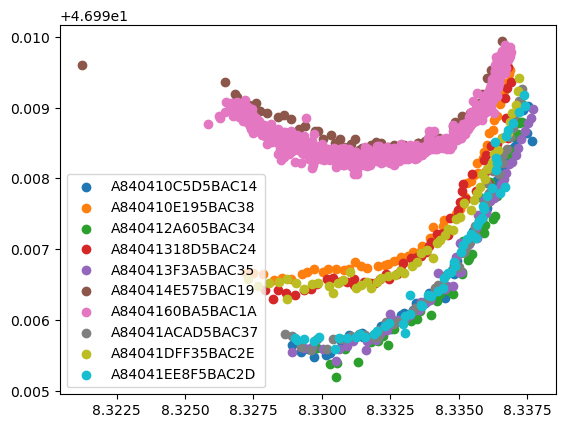

In [63]:
for id_drifter in np.unique(df_filtered['deveui']):
    df_dev = df_filtered[df_filtered['deveui'] == id_drifter]
    plt.scatter(df_dev['lon'], df_dev['lat'], label=id_drifter)
    plt.legend()